In [142]:
from sqlite3 import OperationalError
from datetime import datetime, timedelta, timezone
from pathlib import Path
import uuid

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import quantstats as qs

from ibkr_data.db import table_name, get_connection

conn = get_connection()
cal = mcal.get_calendar("NYSE")

In [143]:
start = (datetime.now(timezone.utc) - timedelta(days=365*5)).date()
end = datetime.now(timezone.utc).date()

schedule = cal.schedule(start_date=start, end_date=end)
market_days = [d.date() for d in schedule.index]
print(f"{len(market_days)} market days from {start} to {end}")

1255 market days from 2021-06-10 to 2026-06-09


In [144]:

def get_tickers():
    ticker_limit = 100
    order_by = "random() DESC NULLS LAST"
    tickers = conn.execute(
        f"""
        SELECT symbol FROM tickers t
        WHERE 'ibkr_' || t.symbol || '_5m' IN (
            SELECT name FROM sqlite_schema WHERE type='table' AND name LIKE 'ibkr_%_5m'
        )
        ORDER BY {order_by}
        LIMIT ?;
        """,
        (ticker_limit,)
    ).fetchall()
    tickers = [r[0] for r in tickers]
    print(f"{len(tickers)} tickers")

    print(tickers)
    return tickers


In [145]:
# IBKR Pro Tiered fees (US stocks, ≤ 300K shares/month)
commission_per_share = 0.0035    # IBKR base commission
exchange_fee = 0.0030            # Exchange pass-through (taking liquidity, blended)
clearing_fee = 0.0002            # NSCC/DTC clearing
finra_cat = 0.000003             # FINRA CAT
sec_fee_rate = 0.0000206         # SEC fee on sells only
minimum_per_order = 0.35
maximum_per_order_pct = 0.01     # 1% of trade value

def trade_cost(shares, price, sell=False):
    """IBKR Pro Tiered all-in cost for one side of a US stock trade."""
    per_share = commission_per_share + exchange_fee + clearing_fee + finra_cat
    fee = max(shares * per_share, minimum_per_order)
    fee = min(fee, shares * price * maximum_per_order_pct)
    if sell:
        fee += shares * price * sec_fee_rate  # SEC fee on sells
    return fee



In [146]:
slippage = 0.0001    
risk_per_trade = 0.01   # 1% of AUM risked per trade
best_n_stocks = 5
atr_distance = 0.1
relative_volume_threshold = 2.
equity = []
portfolio_value = 1_000
trade_count = 0
total_fees = 0.0
trade_fees = []

monthly_data_fee = 4.5
last_month = None

In [147]:

for day in market_days:
    daily_opening_range_volume = []
    tickers = get_tickers()
    for ticker in tickers:
        tbl = table_name(ticker, timeframe="5m_first")
        try:
            row = conn.execute(
                f"SELECT ts, relative_volume FROM [{tbl}] WHERE date(ts) = ? and relative_volume is not null",
                (day.isoformat(),),
            ).fetchone()
        except OperationalError:
            row = None

        if row is None:
            continue

        daily_opening_range_volume.append((ticker, row[1]))

    daily_opening_range_volume = sorted(
        daily_opening_range_volume, key=lambda x: x[1], reverse=True
    )

    stocks_in_play = daily_opening_range_volume[:best_n_stocks]

    trade_made_today = False
    for stock in stocks_in_play:
        if stock[1] < relative_volume_threshold:
            continue
        five_min_table = table_name(ticker=stock[0], timeframe="5m")
        daily_table = table_name(ticker=stock[0], timeframe="1d")

        five_min = conn.execute(
            f"select ts, open, high, low, close from [{five_min_table}] where date(ts) = ? order by ts asc",
            (day.isoformat(),),
        ).fetchall()

        daily = conn.execute(
            f"select atr, close from [{daily_table}] where date(ts) = ?",
            (day.isoformat(),),
        ).fetchone()

        if not five_min or not daily:
            continue

        first_low = five_min[0][3]
        first_high = five_min[0][2]
        first_open = five_min[0][1]
        first_close = five_min[0][4]

        delta = np.sign(first_close - first_open)

        direction = np.sign(delta)
        stop_loss = daily[0] * atr_distance
        if daily[0] is None or np.isnan(daily[0]):
            continue

        long_signal = direction == 1
        short_signal = direction == -1
        

        if short_signal:
            stop_order_entry = first_low
            stop_order_stop_loss = first_low + stop_loss
        elif long_signal:
            stop_order_entry = first_high
            stop_order_stop_loss = first_high - stop_loss
        else:
            continue

        is_trade_open = False
        entry_price = 0
        shares = 0

        for candle in five_min[1:-1]:
            
            low, high = candle[3], candle[2]
            if not is_trade_open:
                if short_signal and not trade_made_today and low <= stop_order_entry:
                    entry_price = stop_order_entry * (1 - slippage)
                    risk_distance = abs(stop_order_stop_loss - entry_price)
                    shares = int((portfolio_value * risk_per_trade) / risk_distance) if risk_distance > 0 and portfolio_value == portfolio_value else 0
                    if shares:
                        fee = trade_cost(shares, entry_price, sell=True)
                        portfolio_value += shares * entry_price - fee
                        trade_count += 1
                        total_fees += fee
                        trade_fees.append({"date": day, "fee": fee})
                        is_trade_open = True
                        trade_made_today = True
                elif long_signal and not trade_made_today and high >= stop_order_entry:
                    entry_price = stop_order_entry * (1 + slippage)
                    risk_distance = abs(stop_order_stop_loss - entry_price)
                    shares = int((portfolio_value * risk_per_trade) / risk_distance) if risk_distance > 0 and portfolio_value == portfolio_value else 0
                    if shares:
                        fee = trade_cost(shares, entry_price, sell=False)
                        cost = shares * entry_price + fee
                        if cost > portfolio_value:
                            shares = 0
                            continue
                        portfolio_value -= cost
                        trade_count += 1
                        total_fees += fee
                        trade_fees.append({"date": day, "fee": fee})
                        is_trade_open = True
                        trade_made_today = True
            else:
                if short_signal and high >= stop_order_stop_loss:
                    fee = trade_cost(shares, stop_order_stop_loss, sell=False)
                    portfolio_value -= shares * stop_order_stop_loss + fee
                    total_fees += fee
                    trade_fees.append({"date": day, "fee": fee})
                    is_trade_open = False
                elif long_signal and low <= stop_order_stop_loss:
                    fee = trade_cost(shares, stop_order_stop_loss, sell=True)
                    portfolio_value += shares * stop_order_stop_loss - fee
                    total_fees += fee
                    trade_fees.append({"date": day, "fee": fee})
                    is_trade_open = False
        # --- close any open position at last candle ---
        if is_trade_open:
            last_candle = five_min[-1]
            close_price = last_candle[4]
            if short_signal:
                fee = trade_cost(shares, close_price, sell=False)
                portfolio_value -= shares * close_price + fee
                total_fees += fee
                trade_fees.append({"date": day, "fee": fee})
            elif long_signal:
                fee = trade_cost(shares, close_price, sell=True)
                portfolio_value += shares * close_price - fee
                total_fees += fee
                trade_fees.append({"date": day, "fee": fee})
            is_trade_open = False
        
        

    # --- track daily portfolio value ---
    equity.append(
        {"date": day, "portfolio_value": portfolio_value, "trade_count": trade_count, "total_fees": total_fees}
    )


    if last_month is not None and day.month != last_month:
        portfolio_value -= monthly_data_fee
    last_month = day.month
    
print(f"{len(equity)} days processed")

100 tickers
['FOXA', 'IRM', 'EBAY', 'GOOGL', 'MDB', 'GOOG', 'LITE', 'MDLZ', 'LRCX', 'APA', 'AJG', 'AXON', 'BAC', 'CSGP', 'OMC', 'MGM', 'DE', 'EXPD', 'GDDY', 'ALLE', 'BR', 'PCAR', 'WMT', 'HOOD', 'MRSH', 'CDNS', 'CAT', 'ITW', 'FANG', 'CMI', 'AMCR', 'MS', 'BXP', 'PCG', 'MTD', 'TSLA', 'AMZN', 'GE', 'DECK', 'APD', 'CTVA', 'ETR', 'EFX', 'DOW', 'LH', 'EXE', 'NXPI', 'PNC', 'LULU', 'CI', 'IQV', 'CASY', 'CNC', 'FTNT', 'LHX', 'AKAM', 'GWW', 'NVDA', 'CARR', 'AWK', 'GM', 'CHRW', 'EVRG', 'PKG', 'CMCSA', 'GPC', 'ES', 'FMC', 'COHR', 'AXP', 'NRG', 'IFF', 'APH', 'OKE', 'HD', 'MOS', 'GS', 'MAS', 'PPL', 'DOV', 'ECL', 'CAG', 'MSCI', 'PH', 'JCI', 'CVNA', 'CEG', 'PRU', 'CPAY', 'AVB', 'CMS', 'BG', 'LYV', 'NVS', 'GD', 'AIG', 'HON', 'CF', 'ENTG', 'CCI']
100 tickers
['APO', 'CARR', 'GOOG', 'JBL', 'IBKR', 'KMB', 'GOOGL', 'MAA', 'NVS', 'HRL', 'NI', 'ENTG', 'DUK', 'ANET', 'BNY', 'PNW', 'BBY', 'CF', 'COHR', 'PHM', 'MET', 'ALGN', 'CPAY', 'PFE', 'PPL', 'OKE', 'EMR', 'MO', 'POOL', 'AVY', 'CBRE', 'ERIE', 'NEM', 'PGR', '

In [148]:
returns = (
    pd.DataFrame(equity)
    .set_index(pd.to_datetime(pd.DataFrame(equity)["date"]))["portfolio_value"]
    .pct_change()
    .dropna()
)

from ibkr_data.db import count_5m_tickers
n_total = count_5m_tickers(conn)

Path("backtests").mkdir(exist_ok=True)
fee_per_share_total = round(commission_per_share + exchange_fee + clearing_fee + finra_cat, 4)
qs.reports.html(returns, output=f"backtests/{uuid.uuid7()}.html", title=f"rv={relative_volume_threshold} atr={atr_distance} n={best_n_stocks} risk={risk_per_trade} fee={fee_per_share_total} min={minimum_per_order} ({len(tickers)}/{n_total} tickers, {order_by} limit {ticker_limit})")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

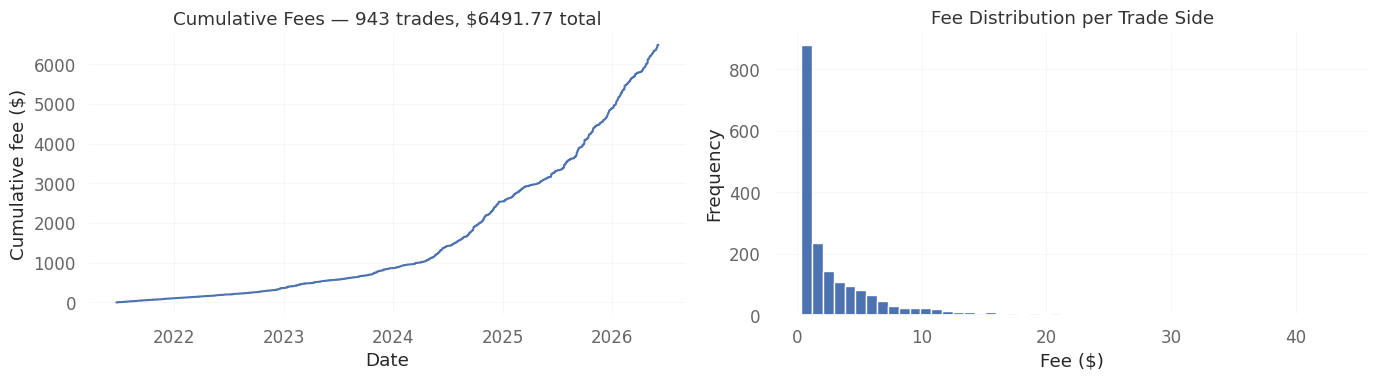

In [149]:
import matplotlib.pyplot as plt

if trade_fees:
    fee_df = pd.DataFrame(trade_fees)
    fee_df["date"] = pd.to_datetime(fee_df["date"])
    fee_df = fee_df.sort_values("date")
    fee_df["cumulative"] = fee_df["fee"].cumsum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(fee_df["date"], fee_df["cumulative"])
    ax1.set_title(f"Cumulative Fees \u2014 {trade_count} trades, ${total_fees:.2f} total")
    ax1.set_ylabel("Cumulative fee ($)")
    ax1.set_xlabel("Date")
    ax1.grid(True, alpha=0.3)

    ax2.hist(fee_df["fee"], bins=50, edgecolor="white")
    ax2.set_title(f"Fee Distribution per Trade Side")
    ax2.set_xlabel("Fee ($)")
    ax2.set_ylabel("Frequency")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No trades made")
